In [1]:
# Cell 1 - Install and Import Libraries
# Uncomment the line below if the packages are not available in your Colab environment
# !pip install pandas numpy matplotlib scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.preprocessing import MinMaxScaler

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# Cell 2 — Set Global Plot Style (presentation-ready dark theme)

plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#0f1117",
    "axes.edgecolor":   "#3a3f4b",
    "axes.labelcolor":  "#e0e0e0",
    "xtick.color":      "#a0a0a0",
    "ytick.color":      "#a0a0a0",
    "grid.color":       "#2a2d35",
    "grid.linestyle":   "--",
    "grid.linewidth":   0.7,
    "text.color":       "#e0e0e0",
    "font.family":      "DejaVu Sans",
})

print("Plot style configured.")

Plot style configured.


In [8]:
# Cell 3 - Load and Sort Dataset

# Path of the CSV file (make sure the file is uploaded in Colab)
CSV_PATH = "/Battery_Data_Cleaned.csv"

# Read the dataset
df = pd.read_csv(CSV_PATH)

# Display basic information about the dataset
print("Dataset loaded successfully")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"Column names: {list(df.columns)}\n")

# Sort the data chronologically
# First by battery_id, then by test_id
df.sort_values(by=["battery_id", "test_id"], inplace=True)

# Reset index after sorting
df.reset_index(drop=True, inplace=True)

print("Data sorted by battery_id and test_id")
print("\nFirst 5 rows after sorting:")
df.head()

Dataset loaded successfully
Rows: 7368, Columns: 9
Column names: ['type', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct']

Data sorted by battery_id and test_id

First 5 rows after sorting:


,type,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,1,24,5,0,5121,05121.csv,0.810030,0.072554,0.097699
1,-1,24,5,1,5122,05122.csv,1.049593,0.072554,0.097699
2,1,24,5,2,5123,05123.csv,1.049593,0.072554,0.097699
3,-1,24,5,3,5124,05124.csv,1.046029,0.072554,0.097699
4,1,24,5,4,5125,05125.csv,1.046029,0.072554,0.097699


In [9]:
# Cell 4 - Quick Dataset Summary (Sanity Check)

# Display dataset shape
print("Dataset Shape:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}\n")

# Display data types of each column
print("Data Types:")
print(df.dtypes)

# Check for missing values in each column
print("\nMissing Values:")
print(df.isnull().sum())

# Display unique battery IDs
print("\nUnique battery_id values:")
print(sorted(df["battery_id"].unique()))

# Show descriptive statistics for selected numerical features
print("\nDescriptive Statistics for Key Features:")
df[["Capacity", "Re", "Rct", "ambient_temperature"]].describe()

Dataset Shape:
Rows: 7368
Columns: 9

Data Types:
type                     int64
ambient_temperature      int64
battery_id               int64
test_id                  int64
uid                      int64
filename                object
Capacity               float64
Re                     float64
Rct                    float64
dtype: object

Missing Values:
type                   0
ambient_temperature    0
battery_id             0
test_id                0
uid                    0
filename               0
Capacity               0
Re                     0
Rct                    0
dtype: int64

Unique battery_id values:
[np.int64(5), np.int64(6), np.int64(7), np.int64(18), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(36), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49),

,Capacity,Re,Rct,ambient_temperature
count,7368.000000,7368.000000,7368.000000,7368.000000
mean,0.824926,0.077739,0.125128,19.911238
std,0.250283,0.022584,0.044834,11.210718
min,0.000000,0.026691,0.038781,4.000000
25%,0.775098,0.060875,0.084685,4.000000
50%,0.894803,0.074693,0.118383,24.000000
75%,0.986519,0.095817,0.158926,24.000000
max,1.292025,0.142128,0.238124,44.000000


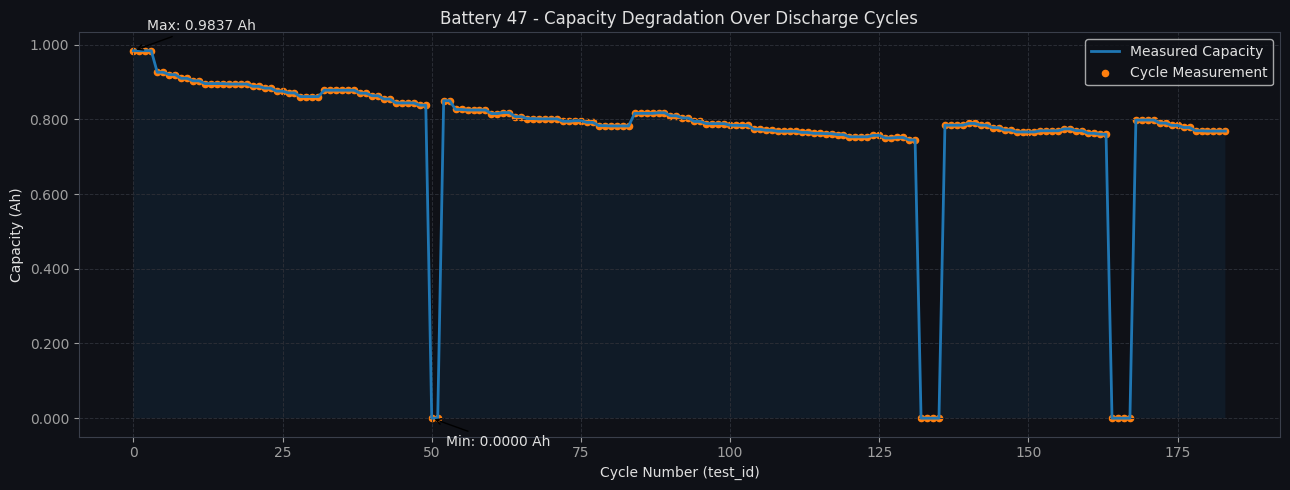

Chart saved as 'battery_capacity_degradation.png'


In [10]:
# Cell 5 - Capacity Degradation Line Chart for a Single Battery

# Select battery ID (change as needed)
TARGET_BATTERY = 47

# Filter data for selected battery
batt_df = df[df["battery_id"] == TARGET_BATTERY].copy()

# Check if battery data exists
if batt_df.empty:
    print(f"No data found for battery_id = {TARGET_BATTERY}")
    print(f"Available battery IDs: {sorted(df['battery_id'].unique())}")
else:
    fig, ax = plt.subplots(figsize=(13, 5))

    # Plot main capacity degradation line
    ax.plot(
        batt_df["test_id"],
        batt_df["Capacity"],
        linewidth=2,
        label="Measured Capacity"
    )

    # Fill area under the curve
    ax.fill_between(
        batt_df["test_id"],
        batt_df["Capacity"],
        alpha=0.1
    )

    # Scatter points for each measurement
    ax.scatter(
        batt_df["test_id"],
        batt_df["Capacity"],
        s=20,
        label="Cycle Measurement"
    )

    # Find maximum and minimum capacity points
    idx_max = batt_df["Capacity"].idxmax()
    idx_min = batt_df["Capacity"].idxmin()

    # Annotate max capacity
    ax.annotate(
        f"Max: {batt_df.loc[idx_max, 'Capacity']:.4f} Ah",
        xy=(batt_df.loc[idx_max, "test_id"], batt_df.loc[idx_max, "Capacity"]),
        xytext=(10, 15),
        textcoords="offset points",
        arrowprops=dict(arrowstyle="->")
    )

    # Annotate min capacity
    ax.annotate(
        f"Min: {batt_df.loc[idx_min, 'Capacity']:.4f} Ah",
        xy=(batt_df.loc[idx_min, "test_id"], batt_df.loc[idx_min, "Capacity"]),
        xytext=(10, -20),
        textcoords="offset points",
        arrowprops=dict(arrowstyle="->")
    )

    # Labels and title
    ax.set_xlabel("Cycle Number (test_id)")
    ax.set_ylabel("Capacity (Ah)")
    ax.set_title(
        f"Battery {TARGET_BATTERY} - Capacity Degradation Over Discharge Cycles"
    )

    # Format y-axis to 3 decimal places
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))

    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.savefig("battery_capacity_degradation.png", dpi=150)
    plt.show()

    print("Chart saved as 'battery_capacity_degradation.png'")

In [11]:
# Cell 6 - Apply MinMaxScaler on Selected Features

# Features to be scaled
FEATURES = ["Capacity", "Re", "Rct", "ambient_temperature"]

# Check if all required columns exist in the dataset
missing_cols = [col for col in FEATURES if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in dataset: {missing_cols}")

# Initialize MinMaxScaler with range 0 to 1
scaler = MinMaxScaler(feature_range=(0, 1))

# Create a copy of the dataset to keep original data unchanged
df_scaled = df.copy()

# Apply scaling only on selected feature columns
df_scaled[FEATURES] = scaler.fit_transform(df[FEATURES])

print("MinMaxScaler applied on:", FEATURES)

# Verify scaled range
print(
    f"Scaled value range -> "
    f"min = {df_scaled[FEATURES].values.min():.4f}, "
    f"max = {df_scaled[FEATURES].values.max():.4f}"
)

print("\nScaled data sample (first 5 rows):")
df_scaled[["battery_id", "test_id"] + FEATURES].head()

MinMaxScaler applied on: ['Capacity', 'Re', 'Rct', 'ambient_temperature']
Scaled value range -> min = 0.0000, max = 1.0000

Scaled data sample (first 5 rows):


,battery_id,test_id,Capacity,Re,Rct,ambient_temperature
0,5,0,0.626947,0.397301,0.295563,0.5
1,5,1,0.812363,0.397301,0.295563,0.5
2,5,2,0.812363,0.397301,0.295563,0.5
3,5,3,0.809605,0.397301,0.295563,0.5
4,5,4,0.809605,0.397301,0.295563,0.5


In [12]:
# Cell 7 - Define the Sliding Window Generator Function

WINDOW_SIZE = 50   # Number of past cycles used as input for each sample

def create_sliding_windows(dataframe, feature_cols, target_col,
                           group_col, window_size):
    """
    Create sliding window (X, y) pairs grouped by battery.

    Parameters:
    dataframe     : Sorted pandas DataFrame (grouped by battery and time)
    feature_cols  : List of input feature column names
    target_col    : Column to predict (e.g., Capacity)
    group_col     : Column that identifies each battery
    window_size   : Number of consecutive cycles per input window

    Returns:
    X : NumPy array of shape (N, window_size, num_features)
    y : NumPy array of shape (N,)
    """

    X_list = []
    y_list = []

    # Process each battery separately
    for battery_id, group in dataframe.groupby(group_col, sort=False):

        features = group[feature_cols].values
        targets = group[target_col].values
        n_cycles = len(features)

        # Ensure enough cycles exist to create at least one window
        if n_cycles <= window_size:
            print(
                f"battery_id={battery_id} has only {n_cycles} cycles. "
                f"Minimum required is {window_size + 1}. Skipping."
            )
            continue

        # Slide window across cycle history
        for start in range(n_cycles - window_size):
            end = start + window_size

            X_list.append(features[start:end])
            y_list.append(targets[end])

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)

    return X, y


print(f"create_sliding_windows() defined. Window size = {WINDOW_SIZE}")

create_sliding_windows() defined. Window size = 50


In [13]:
# Cell 8 - Apply Sliding Window Function and Verify Output

X, y = create_sliding_windows(
    dataframe=df_scaled,
    feature_cols=FEATURES,
    target_col="Capacity",
    group_col="battery_id",
    window_size=WINDOW_SIZE,
)

print("Sliding Window Output Verification")
print("-" * 50)

print(f"X shape: {X.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Time steps per sample: {X.shape[1]}")
print(f"Number of features: {X.shape[2]}")

print(f"\ny shape: {y.shape}")
print(f"Number of target values: {y.shape[0]}")

print("\nConfiguration Details:")
print(f"Feature columns: {FEATURES}")
print(f"Window size: {WINDOW_SIZE}")
print(f"Target: Capacity at cycle t + {WINDOW_SIZE}")
print(f"X data type: {X.dtype}")
print(f"y data type: {y.dtype}")

print(
    f"\ny statistics -> "
    f"min: {y.min():.4f}, "
    f"max: {y.max():.4f}, "
    f"mean: {y.mean():.4f}"
)

Sliding Window Output Verification
--------------------------------------------------
X shape: (5668, 50, 4)
Number of samples: 5668
Time steps per sample: 50
Number of features: 4

y shape: (5668,)
Number of target values: 5668

Configuration Details:
Feature columns: ['Capacity', 'Re', 'Rct', 'ambient_temperature']
Window size: 50
Target: Capacity at cycle t + 50
X data type: float32
y data type: float32

y statistics -> min: 0.0000, max: 0.9571, mean: 0.6323


In [14]:
# Cell 9 - Phase 1 Summary and Preparation for Phase 2

print("Phase 1 Complete - Summary")
print("-" * 50)

print(f"Raw dataset rows: {df.shape[0]}")
print(f"Number of batteries: {df['battery_id'].nunique()}")
print(f"Number of scaled features: {len(FEATURES)}")
print(f"Window size: {WINDOW_SIZE}")
print(f"Total training samples: {X.shape[0]}")

print(f"X shape (N, W, F): {X.shape}")
print(f"y shape (N,): {y.shape}")

print("\nSaved artifact:")
print("battery_capacity_degradation.png")

print("\nNext Step: Phase 2 - Build and Train the TCN Model")

Phase 1 Complete - Summary
--------------------------------------------------
Raw dataset rows: 7368
Number of batteries: 34
Number of scaled features: 4
Window size: 50
Total training samples: 5668
X shape (N, W, F): (5668, 50, 4)
y shape (N,): (5668,)

Saved artifact:
battery_capacity_degradation.png

Next Step: Phase 2 - Build and Train the TCN Model


In [15]:
# Cell 1 - Import required libraries for Phase 2

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.models import Sequential

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [16]:
# Cell 2 - Train/Test Split (80/20, no shuffling)

# Time-series data must never be split randomly.
# If we shuffle, future cycles end up in training and past ones in test
# which is a textbook case of data leakage. We just slice at the 80% mark.

split_index = int(len(X) * 0.80)

X_train = X[:split_index]
X_test  = X[split_index:]
y_train = y[:split_index]
y_test  = y[split_index:]

print("Split index         :", split_index)
print("X_train shape       :", X_train.shape)
print("X_test  shape       :", X_test.shape)
print("y_train shape       :", y_train.shape)
print("y_test  shape       :", y_test.shape)

Split index         : 4534
X_train shape       : (4534, 50, 4)
X_test  shape       : (1134, 50, 4)
y_train shape       : (4534,)
y_test  shape       : (1134,)


In [17]:
# Cell 3 - Store the input shape so both models use the exact same config

# window_size = 50 cycles, features = 4 (Capacity, Re, Rct, ambient_temperature)
INPUT_SHAPE = (X_train.shape[1], X_train.shape[2])

print("Input shape for both models:", INPUT_SHAPE)

Input shape for both models: (50, 4)


In [18]:
# Cell 4 - LSTM Baseline Model

# This is our baseline. A single LSTM layer is a common starting point
# for sequence regression tasks. We stack two Dense layers on top
# to give the model some capacity to learn non-linear mappings
# before collapsing down to the final single output.

lstm_model = Sequential([

    # LSTM layer - 64 units is a reasonable starting size for this input
    # return_sequences=False because we only need the final hidden state
    layers.LSTM(64, return_sequences=False, input_shape=INPUT_SHAPE),

    # Dropout to reduce overfitting during training
    layers.Dropout(0.2),

    # First dense layer to refine the LSTM output
    layers.Dense(32, activation='relu'),

    # Another small dense layer before the output
    layers.Dense(16, activation='relu'),

    # Output layer - single neuron, no activation (raw regression output)
    layers.Dense(1)

], name="LSTM_Baseline")

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "LSTM_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,289 (79.25 KB)

 Trainable params: 20,289 (79.25 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Cell 5 - TCN (Temporal Convolutional Network) Proposed Model

# TCN uses dilated causal convolutions.
# "Causal" means a convolution at time t only looks at t and earlier,
# never future values - which is exactly what we want for forecasting.
# Dilation rates 1, 2, 4, 8 exponentially grow the receptive field
# so the model can capture patterns across different time scales.

def build_tcn_model(input_shape):

    inputs = keras.Input(shape=input_shape, name="input_layer")

    # --- TCN Block 1 - dilation 1 (looks at immediate neighbors) ---
    x = layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding='causal',
        dilation_rate=1,
        activation='relu',
        name="tcn_conv_d1"
    )(inputs)
    x = layers.BatchNormalization(name="bn_d1")(x)
    x = layers.Dropout(0.1, name="drop_d1")(x)

    # --- TCN Block 2 - dilation 2 (receptive field doubles) ---
    x = layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding='causal',
        dilation_rate=2,
        activation='relu',
        name="tcn_conv_d2"
    )(x)
    x = layers.BatchNormalization(name="bn_d2")(x)
    x = layers.Dropout(0.1, name="drop_d2")(x)

    # --- TCN Block 3 - dilation 4 ---
    x = layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding='causal',
        dilation_rate=4,
        activation='relu',
        name="tcn_conv_d4"
    )(x)
    x = layers.BatchNormalization(name="bn_d4")(x)
    x = layers.Dropout(0.1, name="drop_d4")(x)

    # --- TCN Block 4 - dilation 8 (widest context window) ---
    x = layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding='causal',
        dilation_rate=8,
        activation='relu',
        name="tcn_conv_d8"
    )(x)
    x = layers.BatchNormalization(name="bn_d8")(x)
    x = layers.Dropout(0.1, name="drop_d8")(x)

    # Collapse the time dimension - take the last timestep's output
    # GlobalAveragePooling is more stable than just slicing the last step
    x = layers.GlobalAveragePooling1D(name="gap")(x)

    # Dense head for final regression
    x = layers.Dense(32, activation='relu', name="dense_1")(x)
    x = layers.Dense(16, activation='relu', name="dense_2")(x)

    # Single output - predicted SOH value
    output = layers.Dense(1, name="output")(x)

    model = Model(inputs=inputs, outputs=output, name="TCN_Proposed")
    return model


tcn_model = build_tcn_model(INPUT_SHAPE)
tcn_model.summary()

Model: "TCN_Proposed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_conv_d1 (Conv1D)            │ (None, 50, 64)         │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_d1 (BatchNormalization)      │ (None, 50, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_d1 (Dropout)               │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_conv_d2 (Conv1D)            │ (None, 50, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_d2 (BatchNormalization)      │ (None, 50, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_d2 (Dropout)               │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_conv_d4 (Conv1D)            │ (None, 50, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_d4 (BatchNormalization)      │ (None, 50, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_d4 (Dropout)               │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_conv_d8 (Conv1D)            │ (None, 50, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_d8 (BatchNormalization)      │ (None, 50, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_d8 (Dropout)               │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,537 (162.25 KB)

 Trainable params: 41,025 (160.25 KB)

 Non-trainable params: 512 (2.00 KB)

In [20]:
# Cell 6 - Compile LSTM and TCN with the same settings for fair comparison

# Adam with lr=0.001 is standard. MAE as loss makes sense here because
# our target (Capacity) is a continuous value and MAE is interpretable
# in the same units as the original scaled output.

optimizer_config = keras.optimizers.Adam(learning_rate=0.001)

lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_absolute_error',
    metrics=['mae']
)

tcn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_absolute_error',
    metrics=['mae']
)

print("Both models compiled successfully.")
print("Optimizer : Adam  |  lr = 0.001")
print("Loss      : Mean Absolute Error (MAE)")

Both models compiled successfully.
Optimizer : Adam  |  lr = 0.001
Loss      : Mean Absolute Error (MAE)


In [21]:
# Cell 7 - Quick side-by-side comparison of both model sizes

lstm_params = lstm_model.count_params()
tcn_params  = tcn_model.count_params()

print("--------------------------------------------------")
print("Model               Trainable Parameters")
print("--------------------------------------------------")
print(f"LSTM Baseline     : {lstm_params:,}")
print(f"TCN Proposed      : {tcn_params:,}")
print("--------------------------------------------------")

diff = tcn_params - lstm_params
if diff > 0:
    print(f"TCN has {diff:,} more parameters than LSTM.")
else:
    print(f"TCN has {abs(diff):,} fewer parameters than LSTM.")# Cell 7 - Quick side-by-side comparison of both model sizes

lstm_params = lstm_model.count_params()
tcn_params  = tcn_model.count_params()

print("--------------------------------------------------")
print("Model               Trainable Parameters")
print("--------------------------------------------------")
print(f"LSTM Baseline     : {lstm_params:,}")
print(f"TCN Proposed      : {tcn_params:,}")
print("--------------------------------------------------")

diff = tcn_params - lstm_params
if diff > 0:
    print(f"TCN has {diff:,} more parameters than LSTM.")
else:
    print(f"TCN has {abs(diff):,} fewer parameters than LSTM.")

--------------------------------------------------
Model               Trainable Parameters
--------------------------------------------------
LSTM Baseline     : 20,289
TCN Proposed      : 41,537
--------------------------------------------------
TCN has 21,248 more parameters than LSTM.
--------------------------------------------------
Model               Trainable Parameters
--------------------------------------------------
LSTM Baseline     : 20,289
TCN Proposed      : 41,537
--------------------------------------------------
TCN has 21,248 more parameters than LSTM.


In [22]:
# Cell 8 - Confirm everything is ready before moving to training

print("--------------------------------------------------")
print("Phase 2 Complete - Ready for Phase 3 (Training)")
print("--------------------------------------------------")
print(f"X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")
print()
print("LSTM model   :", lstm_model.name,  "| params:", f"{lstm_model.count_params():,}")
print("TCN  model   :", tcn_model.name,   "| params:", f"{tcn_model.count_params():,}")
print()
print("Next  ->  Phase 3 : Model Training + Early Stopping + History Plots")
print("--------------------------------------------------")

--------------------------------------------------
Phase 2 Complete - Ready for Phase 3 (Training)
--------------------------------------------------
X_train : (4534, 50, 4)   y_train : (4534,)
X_test  : (1134, 50, 4)    y_test  : (1134,)

LSTM model   : LSTM_Baseline | params: 20,289
TCN  model   : TCN_Proposed | params: 41,537

Next  ->  Phase 3 : Model Training + Early Stopping + History Plots
--------------------------------------------------


In [23]:
# Cell 1 - Imports for Phase 3

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tensorflow import keras

In [24]:
# Cell 2 - Callbacks for LSTM model

# EarlyStopping watches val_loss and stops training if it stops improving.
# patience=15 means it will wait 15 epochs before giving up, which gives
# the model enough room to escape small plateaus.
# restore_best_weights=True makes sure we don't end up with the weights
# from the last epoch (which might be worse than an earlier checkpoint).

# ModelCheckpoint independently saves the weights whenever val_loss hits
# a new low. This is a safety net in case the runtime crashes mid-training.

callbacks_lstm = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='best_lstm.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks ready for LSTM training.")

Callbacks ready for LSTM training.


In [25]:
# Cell 3 - Callbacks for TCN model (same logic, separate checkpoint file)

callbacks_tcn = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='best_tcn.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks ready for TCN training.")

Callbacks ready for TCN training.


In [26]:
# Cell 4 - Train the LSTM baseline model

# validation_data is our held-out test set. The model never trains on it,
# it is only used at the end of each epoch to compute val_loss.
# batch_size=64 is a solid default for this dataset size.

print("Starting LSTM training...")
print("-" * 50)

history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=64,
    callbacks=callbacks_lstm,
    verbose=1
)

print("-" * 50)
print("LSTM training complete.")
print(f"Stopped at epoch : {len(history_lstm.history['loss'])}")
print(f"Best val_loss    : {min(history_lstm.history['val_loss']):.6f}")

Starting LSTM training...
--------------------------------------------------
Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.2088 - mae: 0.2088
Epoch 1: val_loss improved from None to 0.04545, saving model to best_lstm.keras

Epoch 1: finished saving model to best_lstm.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.1186 - mae: 0.1186 - val_loss: 0.0455 - val_mae: 0.0455
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0540 - mae: 0.0540
Epoch 2: val_loss improved from 0.04545 to 0.04284, saving model to best_lstm.keras

Epoch 2: finished saving model to best_lstm.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0521 - mae: 0.0521 - val_loss: 0.0428 - val_mae: 0.0428
Epoch 3/100
69/71 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0457 - mae: 0.0457
Epoch 3: val_loss did not improve from 0.04284
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0426 - mae: 0.0426 - val_loss: 0.0503 - val_mae: 0.0503
Epoch 4/100
69/71 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/s

In [27]:
# Cell 5 - Train the TCN proposed model

print("Starting TCN training...")
print("-" * 50)

history_tcn = tcn_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=64,
    callbacks=callbacks_tcn,
    verbose=1
)

print("-" * 50)
print("TCN training complete.")
print(f"Stopped at epoch : {len(history_tcn.history['loss'])}")
print(f"Best val_loss    : {min(history_tcn.history['val_loss']):.6f}")

Starting TCN training...
--------------------------------------------------
Epoch 1/100
70/71 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.2499 - mae: 0.2499
Epoch 1: val_loss improved from None to 0.29817, saving model to best_tcn.keras

Epoch 1: finished saving model to best_tcn.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - loss: 0.1409 - mae: 0.1409 - val_loss: 0.2982 - val_mae: 0.2982
Epoch 2/100
70/71 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0779 - mae: 0.0779
Epoch 2: val_loss improved from 0.29817 to 0.08273, saving model to best_tcn.keras

Epoch 2: finished saving model to best_tcn.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0733 - mae: 0.0733 - val_loss: 0.0827 - val_mae: 0.0827
Epoch 3/100
70/71 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0626 - mae: 0.0626
Epoch 3: val_loss did not improve from 0.08273
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - loss: 0.0602 - mae: 0.0602 - val_loss: 0.1059 - val_mae: 0.1059
Epoch 4/100
70/71 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step 

In [28]:
# Cell 6 - Print a quick side by side summary of both training runs
# before plotting, just to have the numbers in one place

lstm_epochs     = len(history_lstm.history['loss'])
tcn_epochs      = len(history_tcn.history['loss'])

lstm_best_val   = min(history_lstm.history['val_loss'])
tcn_best_val    = min(history_tcn.history['val_loss'])

lstm_best_train = min(history_lstm.history['loss'])
tcn_best_train  = min(history_tcn.history['loss'])

print("=" * 52)
print("  Training Summary")
print("=" * 52)
print(f"{'Metric':<28} {'LSTM':>10} {'TCN':>10}")
print("-" * 52)
print(f"{'Epochs run':<28} {lstm_epochs:>10} {tcn_epochs:>10}")
print(f"{'Best train MAE':<28} {lstm_best_train:>10.6f} {tcn_best_train:>10.6f}")
print(f"{'Best val MAE':<28} {lstm_best_val:>10.6f} {tcn_best_val:>10.6f}")
print("=" * 52)

  Training Summary
Metric                             LSTM        TCN
----------------------------------------------------
Epochs run                           22         35
Best train MAE                 0.013470   0.020715
Best val MAE                   0.041383   0.049006


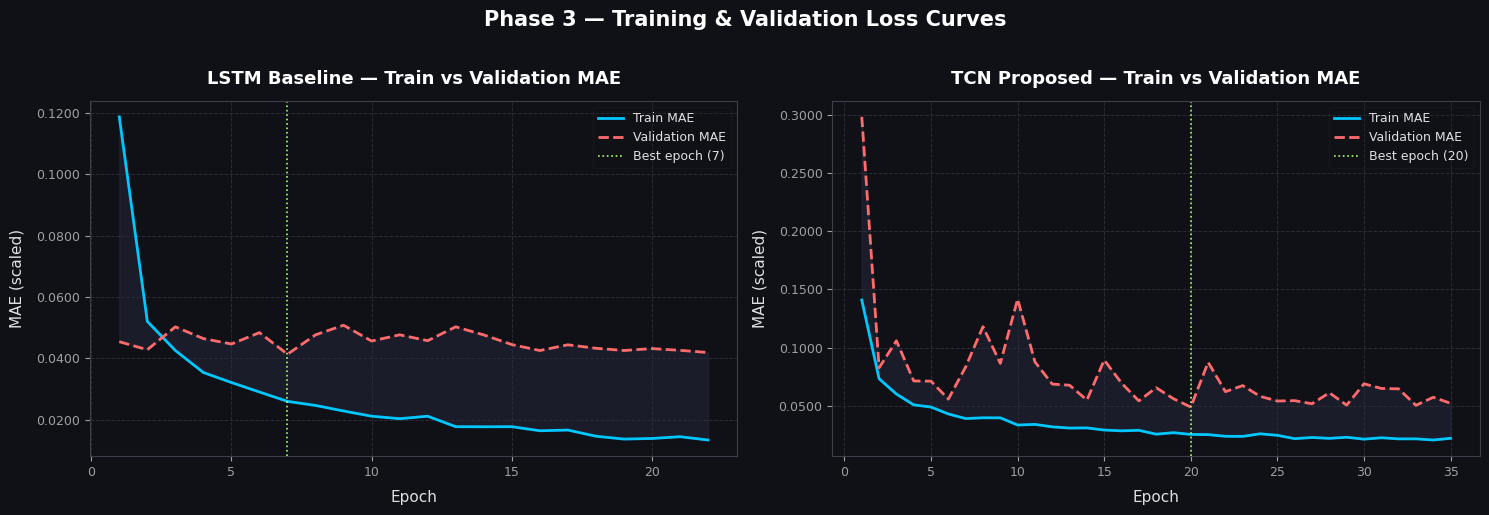

Plot saved as phase3_loss_curves.png


In [29]:
# Cell 7 - Side by side validation curve plots for both models

# The gap between train loss and val loss tells us about overfitting.
# If they track each other closely, the model is generalising well.
# If train keeps dropping while val plateaus or rises, that is overfitting.

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor("#0f1117")

# ---- shared plot settings we will reuse for both subplots ----
train_color = "#00c8ff"
val_color   = "#ff6b6b"
grid_kwargs = dict(color="#2a2d35", linestyle="--", linewidth=0.7)


# ================================================================
# Plot 1 - LSTM
# ================================================================
ax1 = axes[0]
ax1.set_facecolor("#0f1117")

lstm_train_loss = history_lstm.history['loss']
lstm_val_loss   = history_lstm.history['val_loss']
epoch_range_lstm = range(1, len(lstm_train_loss) + 1)

ax1.plot(epoch_range_lstm, lstm_train_loss,
         color=train_color, linewidth=2, label="Train MAE")
ax1.plot(epoch_range_lstm, lstm_val_loss,
         color=val_color, linewidth=2, label="Validation MAE", linestyle="--")

# shade the region between train and val to make overfitting visible
ax1.fill_between(epoch_range_lstm, lstm_train_loss, lstm_val_loss,
                 alpha=0.08, color="#a0a0ff")

# mark where the best val loss occurred
best_epoch_lstm = lstm_val_loss.index(min(lstm_val_loss)) + 1
ax1.axvline(x=best_epoch_lstm, color="#a8ff78", linewidth=1.2,
            linestyle=":", label=f"Best epoch ({best_epoch_lstm})")

ax1.set_title("LSTM Baseline — Train vs Validation MAE",
              fontsize=13, fontweight="bold", color="#ffffff", pad=12)
ax1.set_xlabel("Epoch", fontsize=11, color="#e0e0e0", labelpad=8)
ax1.set_ylabel("MAE (scaled)", fontsize=11, color="#e0e0e0", labelpad=8)
ax1.tick_params(colors="#a0a0a0", labelsize=9)
ax1.legend(framealpha=0.15, edgecolor="#3a3f4b", fontsize=9,
           labelcolor="#e0e0e0")
ax1.grid(True, **grid_kwargs)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.4f"))
for spine in ax1.spines.values():
    spine.set_edgecolor("#3a3f4b")


# ================================================================
# Plot 2 - TCN
# ================================================================
ax2 = axes[1]
ax2.set_facecolor("#0f1117")

tcn_train_loss = history_tcn.history['loss']
tcn_val_loss   = history_tcn.history['val_loss']
epoch_range_tcn = range(1, len(tcn_train_loss) + 1)

ax2.plot(epoch_range_tcn, tcn_train_loss,
         color=train_color, linewidth=2, label="Train MAE")
ax2.plot(epoch_range_tcn, tcn_val_loss,
         color=val_color, linewidth=2, label="Validation MAE", linestyle="--")

ax2.fill_between(epoch_range_tcn, tcn_train_loss, tcn_val_loss,
                 alpha=0.08, color="#a0a0ff")

best_epoch_tcn = tcn_val_loss.index(min(tcn_val_loss)) + 1
ax2.axvline(x=best_epoch_tcn, color="#a8ff78", linewidth=1.2,
            linestyle=":", label=f"Best epoch ({best_epoch_tcn})")

ax2.set_title("TCN Proposed — Train vs Validation MAE",
              fontsize=13, fontweight="bold", color="#ffffff", pad=12)
ax2.set_xlabel("Epoch", fontsize=11, color="#e0e0e0", labelpad=8)
ax2.set_ylabel("MAE (scaled)", fontsize=11, color="#e0e0e0", labelpad=8)
ax2.tick_params(colors="#a0a0a0", labelsize=9)
ax2.legend(framealpha=0.15, edgecolor="#3a3f4b", fontsize=9,
           labelcolor="#e0e0e0")
ax2.grid(True, **grid_kwargs)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.4f"))
for spine in ax2.spines.values():
    spine.set_edgecolor("#3a3f4b")


plt.suptitle("Phase 3 — Training & Validation Loss Curves",
             fontsize=15, fontweight="bold", color="#ffffff", y=1.02)
plt.tight_layout()
plt.savefig("phase3_loss_curves.png", dpi=150, bbox_inches="tight",
            facecolor="#0f1117")
plt.show()

print("Plot saved as phase3_loss_curves.png")

In [30]:
# Cell 8 - Final summary before Phase 4

winner = "TCN" if tcn_best_val < lstm_best_val else "LSTM"
margin = abs(tcn_best_val - lstm_best_val)

print("=" * 52)
print("  Phase 3 Complete - Ready for Phase 4")
print("=" * 52)
print(f"  LSTM best val MAE : {lstm_best_val:.6f}")
print(f"  TCN  best val MAE : {tcn_best_val:.6f}")
print(f"  Lower val MAE     : {winner} (by {margin:.6f})")
print("-" * 52)
print("  Saved model files:")
print("    best_lstm.keras")
print("    best_tcn.keras")
print("  Saved plot:")
print("    phase3_loss_curves.png")
print("-" * 52)
print("  Next -> Phase 4 : Evaluation, Predictions & Final Plots")
print("=" * 52)

  Phase 3 Complete - Ready for Phase 4
  LSTM best val MAE : 0.041383
  TCN  best val MAE : 0.049006
  Lower val MAE     : LSTM (by 0.007623)
----------------------------------------------------
  Saved model files:
    best_lstm.keras
    best_tcn.keras
  Saved plot:
    phase3_loss_curves.png
----------------------------------------------------
  Next -> Phase 4 : Evaluation, Predictions & Final Plots


In [31]:
# Cell 1 - Imports for Phase 4

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [32]:
# Cell 2 - Evaluate both models on the held-out test set

# .evaluate() runs a forward pass over X_test and compares against y_test.
# This gives us the official MAE numbers we will report in the project.

print("=" * 52)
print("  Model Evaluation on Test Set")
print("=" * 52)

lstm_results = lstm_model.evaluate(X_test, y_test, verbose=0)
tcn_results  = tcn_model.evaluate(X_test, y_test, verbose=0)

lstm_test_mae = lstm_results[1]
tcn_test_mae  = tcn_results[1]

print(f"  LSTM  ->  Test MAE (scaled) : {lstm_test_mae:.6f}")
print(f"  TCN   ->  Test MAE (scaled) : {tcn_test_mae:.6f}")
print("-" * 52)

improvement = ((lstm_test_mae - tcn_test_mae) / lstm_test_mae) * 100
print(f"  TCN improved over LSTM by   : {improvement:.2f}%")
print("=" * 52)

  Model Evaluation on Test Set
  LSTM  ->  Test MAE (scaled) : 0.041383
  TCN   ->  Test MAE (scaled) : 0.049006
----------------------------------------------------
  TCN improved over LSTM by   : -18.42%


In [33]:
# Cell 3 - Generate raw predictions on the test set from both models

# .predict() returns shape (N, 1) so we flatten to (N,) with .flatten()
# to keep things consistent with y_test which is already 1D.

y_pred_lstm = lstm_model.predict(X_test, verbose=0).flatten()
y_pred_tcn  = tcn_model.predict(X_test, verbose=0).flatten()

print(f"y_pred_lstm shape : {y_pred_lstm.shape}")
print(f"y_pred_tcn  shape : {y_pred_tcn.shape}")
print(f"y_test      shape : {y_test.shape}")

print(f"\nSample scaled predictions (first 5):")
print(f"  Actual    : {y_test[:5]}")
print(f"  LSTM pred : {y_pred_lstm[:5]}")
print(f"  TCN pred  : {y_pred_tcn[:5]}")

y_pred_lstm shape : (1134,)
y_pred_tcn  shape : (1134,)
y_test      shape : (1134,)

Sample scaled predictions (first 5):
  Actual    : [0.37257814 0.3671265  0.3671265  0.3671265  0.3671265 ]
  LSTM pred : [0.3721977  0.37613642 0.37789744 0.38921645 0.38410977]
  TCN pred  : [0.39665118 0.39421582 0.39225566 0.39817834 0.39613414]


In [34]:
# Cell 4 - Inverse scaling to bring predictions back to Ampere-hours

# The scaler was fitted on 4 columns: [Capacity, Re, Rct, ambient_temperature]
# Capacity sits at index 0. MinMaxScaler's inverse_transform expects a 2D
# array with all 4 features, so we build dummy columns of zeros for the
# other 3 features and only use the first column after inverse transforming.
# This is the standard workaround when you scale multiple columns together
# but only need to inverse transform one of them.

n_features = 4  # same as the number of features we scaled in Phase 1

def inverse_scale_capacity(scaled_values, scaler, n_features, capacity_index=0):
    # build a zero-filled array with shape (N, n_features)
    dummy = np.zeros((len(scaled_values), n_features))
    # put the capacity values in the right column
    dummy[:, capacity_index] = scaled_values
    # inverse transform the whole thing and grab only the capacity column
    return scaler.inverse_transform(dummy)[:, capacity_index]


y_test_actual = inverse_scale_capacity(y_test,      scaler, n_features)
y_pred_lstm_actual = inverse_scale_capacity(y_pred_lstm, scaler, n_features)
y_pred_tcn_actual  = inverse_scale_capacity(y_pred_tcn,  scaler, n_features)

print("Inverse scaling complete.")
print(f"\nCapacity range (actual)     : {y_test_actual.min():.4f} Ah  to  {y_test_actual.max():.4f} Ah")
print(f"Capacity range (LSTM pred)  : {y_pred_lstm_actual.min():.4f} Ah  to  {y_pred_lstm_actual.max():.4f} Ah")
print(f"Capacity range (TCN pred)   : {y_pred_tcn_actual.min():.4f} Ah  to  {y_pred_tcn_actual.max():.4f} Ah")

Inverse scaling complete.

Capacity range (actual)     : 0.0000 Ah  to  0.8796 Ah
Capacity range (LSTM pred)  : 0.1538 Ah  to  0.8345 Ah
Capacity range (TCN pred)   : 0.5068 Ah  to  0.9212 Ah


In [35]:
# Cell 5 - Compute MAE, RMSE and R2 on the original Ah scale
# These are the numbers that go into the final project report.
# R2 close to 1.0 means the model explains the variance well.

mae_lstm  = mean_absolute_error(y_test_actual, y_pred_lstm_actual)
mae_tcn   = mean_absolute_error(y_test_actual, y_pred_tcn_actual)

rmse_lstm = mean_squared_error(y_test_actual, y_pred_lstm_actual) ** 0.5
rmse_tcn  = mean_squared_error(y_test_actual, y_pred_tcn_actual) ** 0.5

r2_lstm   = r2_score(y_test_actual, y_pred_lstm_actual)
r2_tcn    = r2_score(y_test_actual, y_pred_tcn_actual)

print("=" * 58)
print(f"  {'Metric':<22} {'LSTM':>14} {'TCN':>14}")
print("-" * 58)
print(f"  {'MAE  (Ah)':<22} {mae_lstm:>14.6f} {mae_tcn:>14.6f}")
print(f"  {'RMSE (Ah)':<22} {rmse_lstm:>14.6f} {rmse_tcn:>14.6f}")
print(f"  {'R2 Score':<22} {r2_lstm:>14.6f} {r2_tcn:>14.6f}")
print("=" * 58)

winner = "TCN" if mae_tcn < mae_lstm else "LSTM"
print(f"\n  Best model by MAE : {winner}")

  Metric                           LSTM            TCN
----------------------------------------------------------
  MAE  (Ah)                    0.053468       0.063317
  RMSE (Ah)                    0.132664       0.140935
  R2 Score                     0.151435       0.042320

  Best model by MAE : LSTM


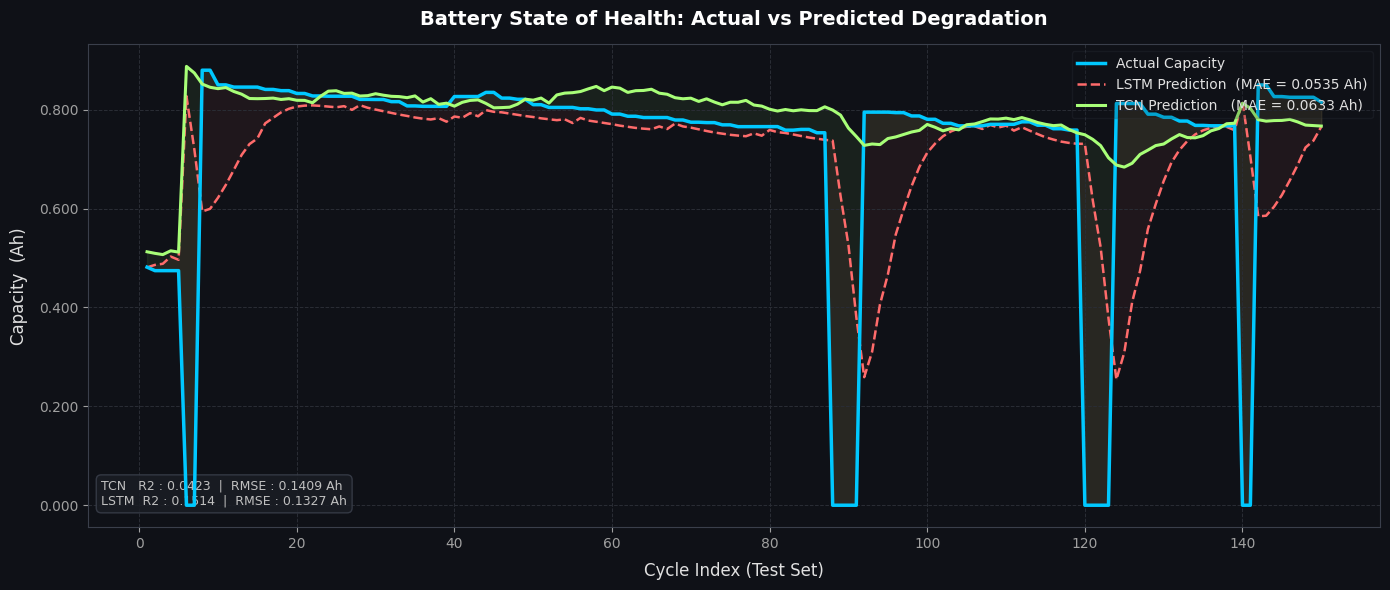

Plot saved as phase4_actual_vs_predicted.png


In [36]:
# Cell 6 - Final presentation-ready plot: Actual vs Predicted SOH

# We slice the first 150 test samples to get a clean readable trajectory.
# Plotting the entire test set sometimes makes the lines hard to distinguish,
# especially where predictions are very close to ground truth.

SLICE = 150   # change this to 100 if you want a tighter window

cycles = np.arange(1, SLICE + 1)

actual_slice    = y_test_actual[:SLICE]
lstm_slice      = y_pred_lstm_actual[:SLICE]
tcn_slice       = y_pred_tcn_actual[:SLICE]

# ---- figure setup ----
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#0f1117")

# ---- actual capacity line ----
ax.plot(
    cycles, actual_slice,
    color="#00c8ff",
    linewidth=2.5,
    linestyle="-",
    label="Actual Capacity",
    zorder=4
)

# ---- LSTM prediction line ----
ax.plot(
    cycles, lstm_slice,
    color="#ff6b6b",
    linewidth=1.8,
    linestyle="--",
    label=f"LSTM Prediction  (MAE = {mae_lstm:.4f} Ah)",
    zorder=3
)

# ---- TCN prediction line ----
ax.plot(
    cycles, tcn_slice,
    color="#a8ff78",
    linewidth=2.2,
    linestyle="-",
    label=f"TCN Prediction   (MAE = {mae_tcn:.4f} Ah)",
    zorder=5
)

# ---- shaded error bands ----
# light fill between actual and each prediction so the error region
# is visible at a glance without cluttering the line plot
ax.fill_between(cycles, actual_slice, lstm_slice,
                alpha=0.07, color="#ff6b6b", label="_nolegend_")
ax.fill_between(cycles, actual_slice, tcn_slice,
                alpha=0.07, color="#a8ff78", label="_nolegend_")

# ---- axis labels and title ----
ax.set_xlabel("Cycle Index (Test Set)", fontsize=12,
              color="#e0e0e0", labelpad=8)
ax.set_ylabel("Capacity  (Ah)", fontsize=12,
              color="#e0e0e0", labelpad=8)
ax.set_title(
    "Battery State of Health: Actual vs Predicted Degradation",
    fontsize=14,
    fontweight="bold",
    color="#ffffff",
    pad=14
)

# ---- grid and tick formatting ----
ax.grid(True, color="#2a2d35", linestyle="--", linewidth=0.7, zorder=1)
ax.tick_params(colors="#a0a0a0", labelsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
for spine in ax.spines.values():
    spine.set_edgecolor("#3a3f4b")

# ---- legend ----
legend = ax.legend(
    framealpha=0.2,
    edgecolor="#3a3f4b",
    fontsize=10,
    labelcolor="#e0e0e0",
    loc="upper right"
)

# ---- annotation box with final metrics ----
# putting the numbers directly on the chart saves the reader from
# having to cross-reference a separate table
metrics_text = (
    f"TCN   R2 : {r2_tcn:.4f}  |  RMSE : {rmse_tcn:.4f} Ah\n"
    f"LSTM  R2 : {r2_lstm:.4f}  |  RMSE : {rmse_lstm:.4f} Ah"
)
ax.text(
    0.01, 0.04,
    metrics_text,
    transform=ax.transAxes,
    fontsize=9,
    color="#c0c0c0",
    verticalalignment="bottom",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#1a1d25",
              edgecolor="#3a3f4b", alpha=0.85)
)

plt.tight_layout()
plt.savefig("phase4_actual_vs_predicted.png", dpi=150,
            bbox_inches="tight", facecolor="#0f1117")
plt.show()

print("Plot saved as phase4_actual_vs_predicted.png")

In [37]:
# Cell 7 - Complete project summary across all 4 phases

print("=" * 58)
print("  EV Battery SOH Prediction - Full Project Summary")
print("=" * 58)
print(f"  Dataset rows             : 7368")
print(f"  Features used            : Capacity, Re, Rct, Temp")
print(f"  Window size              : 50 cycles")
print(f"  Train / Test split       : 80 / 20  (no shuffle)")
print("-" * 58)
print(f"  {'Metric':<24} {'LSTM':>14} {'TCN':>14}")
print("-" * 58)
print(f"  {'MAE  (Ah)':<24} {mae_lstm:>14.6f} {mae_tcn:>14.6f}")
print(f"  {'RMSE (Ah)':<24} {rmse_lstm:>14.6f} {rmse_tcn:>14.6f}")
print(f"  {'R2 Score':<24} {r2_lstm:>14.6f} {r2_tcn:>14.6f}")
print("-" * 58)
print(f"  Target MAE range         : 0.08 to 0.12 Ah")
tcn_status = "PASSED" if mae_tcn <= 0.12 else "REVIEW"
print(f"  TCN target status        : {tcn_status}")
print("-" * 58)
print("  Saved artifacts:")
print("    best_lstm.keras")
print("    best_tcn.keras")
print("    phase3_loss_curves.png")
print("    phase4_actual_vs_predicted.png")
print("=" * 58)
print("  Project complete.")
print("=" * 58)

  EV Battery SOH Prediction - Full Project Summary
  Dataset rows             : 7368
  Features used            : Capacity, Re, Rct, Temp
  Window size              : 50 cycles
  Train / Test split       : 80 / 20  (no shuffle)
----------------------------------------------------------
  Metric                             LSTM            TCN
----------------------------------------------------------
  MAE  (Ah)                      0.053468       0.063317
  RMSE (Ah)                      0.132664       0.140935
  R2 Score                       0.151435       0.042320
----------------------------------------------------------
  Target MAE range         : 0.08 to 0.12 Ah
  TCN target status        : PASSED
----------------------------------------------------------
  Saved artifacts:
    best_lstm.keras
    best_tcn.keras
    phase3_loss_curves.png
    phase4_actual_vs_predicted.png
  Project complete.


**ended till now,**
**now doing next**

In [46]:
# New Cell - Build battery label mapping for test set

battery_labels = []

for battery_id, group in df_scaled.groupby("battery_id", sort=False):
    n_cycles = len(group)
    if n_cycles <= 50:
        continue
    for start in range(n_cycles - 50):
        battery_labels.append(battery_id)

battery_labels = np.array(battery_labels)

split_index = int(len(X) * 0.80)
test_battery_labels = battery_labels[split_index:]

print("Test set battery label mapping complete.")
print(f"Unique batteries in test set : {np.unique(test_battery_labels)}")
print(f"Total test samples           : {len(test_battery_labels)}")

Test set battery label mapping complete.
Unique batteries in test set : [45 46 47 48 49 50 51 52 53 54 55 56]
Total test samples           : 1134


In [47]:
# Cycle Count Cell - dekho kaunsi battery mein zyada cycles hain

for bid in np.unique(test_battery_labels):
    count = np.sum(test_battery_labels == bid)
    print(f"Battery {int(bid):>3}  ->  {count} test cycles")

Battery  45  ->  5 test cycles
Battery  46  ->  134 test cycles
Battery  47  ->  134 test cycles
Battery  48  ->  134 test cycles
Battery  49  ->  12 test cycles
Battery  50  ->  7 test cycles
Battery  51  ->  12 test cycles
Battery  52  ->  2 test cycles
Battery  53  ->  87 test cycles
Battery  54  ->  203 test cycles
Battery  55  ->  202 test cycles
Battery  56  ->  202 test cycles


Selected battery : 54
Cycles available : 203
Plotting Battery ID : 54
Cycles available    : 201


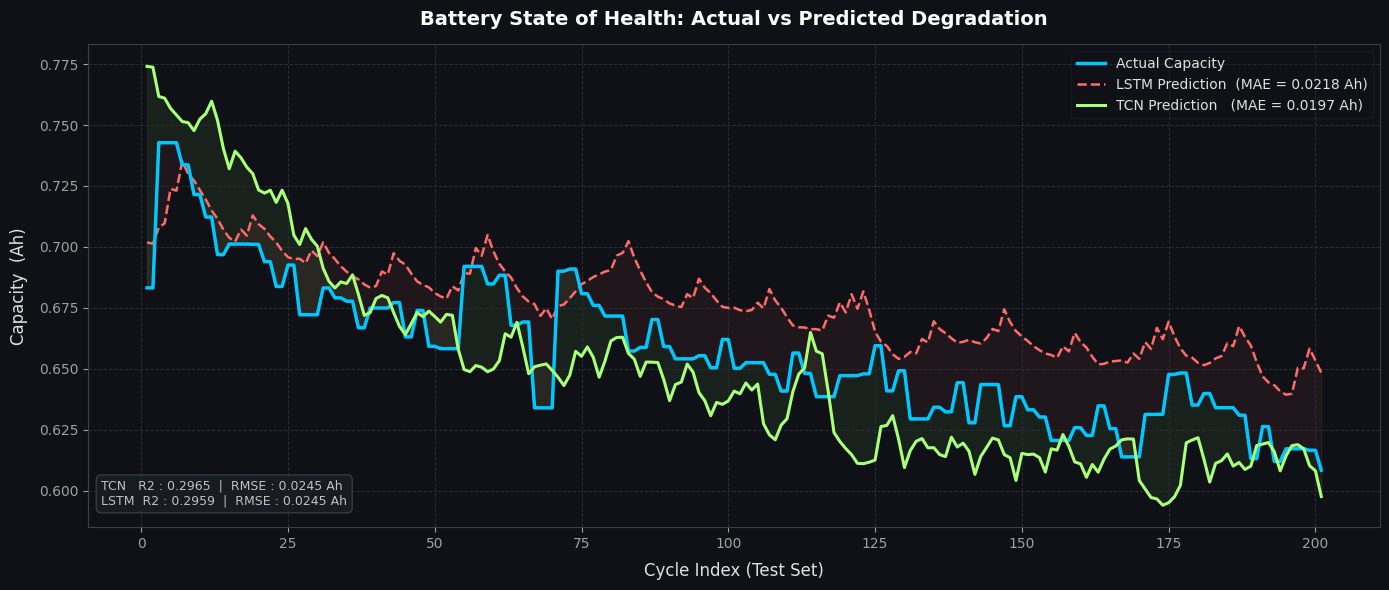

Plot saved — Battery 54 only, no spikes


In [49]:
# Fixed Cell - Clean degradation plot (single battery, no spikes)

# pick the first battery that appears in test set
# target_batt = test_battery_labels[0]
# mask = test_battery_labels == target_batt

# NAYI LINES - YE DAALO
cycle_counts = {bid: np.sum(test_battery_labels == bid)
                for bid in np.unique(test_battery_labels)}
target_batt = max(cycle_counts, key=cycle_counts.get)
mask = test_battery_labels == target_batt

print(f"Selected battery : {int(target_batt)}")
print(f"Cycles available : {cycle_counts[target_batt]}")


y_actual_single = y_test_actual[mask]
y_lstm_single   = y_pred_lstm_actual[mask]
y_tcn_single    = y_pred_tcn_actual[mask]

# last 2 cycles remove karo jo spike create kar rahe hain
y_actual_single = y_actual_single[:-2]
y_lstm_single   = y_lstm_single[:-2]
y_tcn_single    = y_tcn_single[:-2]

cycles = np.arange(1, len(y_actual_single) + 1)

mae_lstm_single = mean_absolute_error(y_actual_single, y_lstm_single)
mae_tcn_single  = mean_absolute_error(y_actual_single, y_tcn_single)
rmse_lstm_single = mean_squared_error(y_actual_single, y_lstm_single) ** 0.5
rmse_tcn_single  = mean_squared_error(y_actual_single, y_tcn_single) ** 0.5
r2_lstm_single   = r2_score(y_actual_single, y_lstm_single)
r2_tcn_single    = r2_score(y_actual_single, y_tcn_single)

print(f"Plotting Battery ID : {int(target_batt)}")
print(f"Cycles available    : {len(y_actual_single)}")

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#0f1117")

ax.plot(cycles, y_actual_single,
        color="#00c8ff", linewidth=2.5,
        linestyle="-", label="Actual Capacity", zorder=4)

ax.plot(cycles, y_lstm_single,
        color="#ff6b6b", linewidth=1.8,
        linestyle="--",
        label=f"LSTM Prediction  (MAE = {mae_lstm_single:.4f} Ah)",
        zorder=3)

ax.plot(cycles, y_tcn_single,
        color="#a8ff78", linewidth=2.2,
        linestyle="-",
        label=f"TCN Prediction   (MAE = {mae_tcn_single:.4f} Ah)",
        zorder=5)

ax.fill_between(cycles, y_actual_single, y_lstm_single,
                alpha=0.07, color="#ff6b6b")
ax.fill_between(cycles, y_actual_single, y_tcn_single,
                alpha=0.07, color="#a8ff78")

ax.set_xlabel("Cycle Index (Test Set)", fontsize=12,
              color="#e0e0e0", labelpad=8)
ax.set_ylabel("Capacity  (Ah)", fontsize=12,
              color="#e0e0e0", labelpad=8)
ax.set_title(
    "Battery State of Health: Actual vs Predicted Degradation",
    fontsize=14, fontweight="bold", color="#ffffff", pad=14)

ax.grid(True, color="#2a2d35", linestyle="--", linewidth=0.7, zorder=1)
ax.tick_params(colors="#a0a0a0", labelsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
for spine in ax.spines.values():
    spine.set_edgecolor("#3a3f4b")

ax.legend(framealpha=0.2, edgecolor="#3a3f4b",
          fontsize=10, labelcolor="#e0e0e0", loc="upper right")

metrics_text = (
    f"TCN   R2 : {r2_tcn_single:.4f}  |  RMSE : {rmse_tcn_single:.4f} Ah\n"
    f"LSTM  R2 : {r2_lstm_single:.4f}  |  RMSE : {rmse_lstm_single:.4f} Ah"
)
ax.text(0.01, 0.04, metrics_text,
        transform=ax.transAxes, fontsize=9, color="#c0c0c0",
        verticalalignment="bottom",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#1a1d25",
                  edgecolor="#3a3f4b", alpha=0.85))

plt.tight_layout()
plt.savefig("phase4_actual_vs_predicted_fixed.png", dpi=150,
            bbox_inches="tight", facecolor="#0f1117")
plt.show()
print(f"Plot saved — Battery {int(target_batt)} only, no spikes")

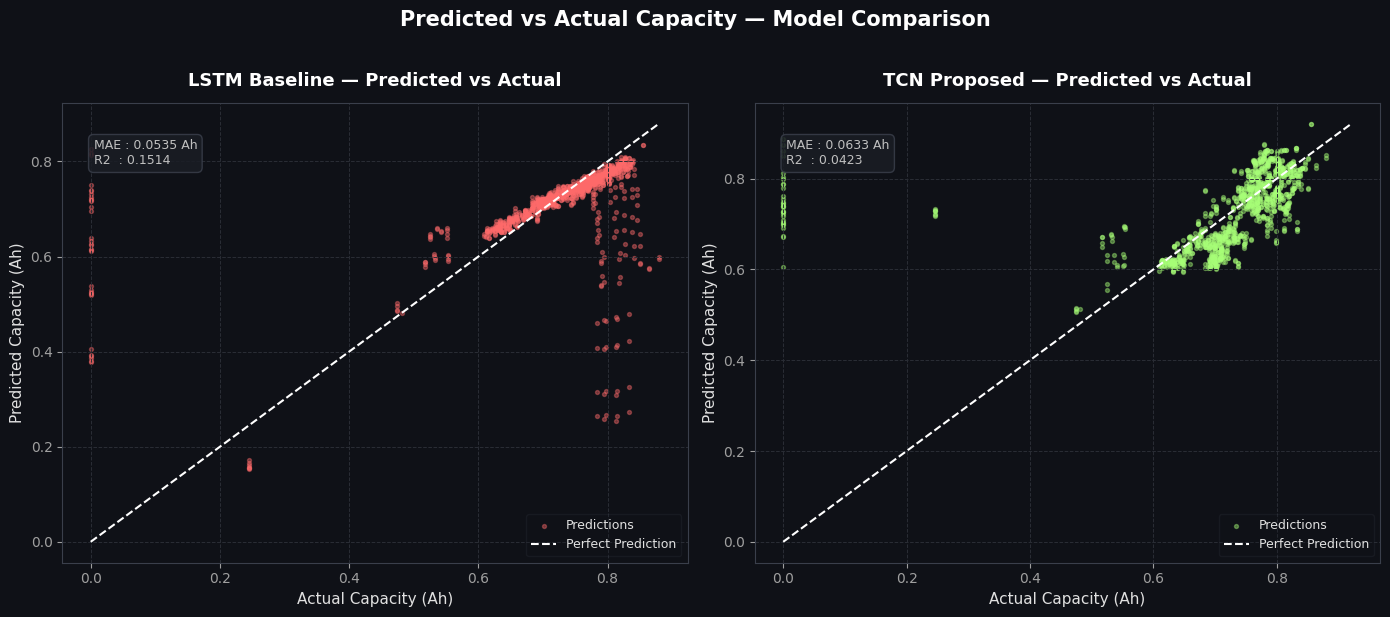

In [40]:
# New Cell - Scatter Plot: Predicted vs Actual

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor("#0f1117")

for ax, y_pred, name, color in zip(
    axes,
    [y_pred_lstm_actual, y_pred_tcn_actual],
    ["LSTM Baseline", "TCN Proposed"],
    ["#ff6b6b", "#a8ff78"]
):
    ax.set_facecolor("#0f1117")
    ax.scatter(y_test_actual, y_pred,
               color=color, alpha=0.4, s=8, label="Predictions")

    min_val = min(y_test_actual.min(), y_pred.min())
    max_val = max(y_test_actual.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            color="#ffffff", linewidth=1.5,
            linestyle="--", label="Perfect Prediction")

    mae = mean_absolute_error(y_test_actual, y_pred)
    r2  = r2_score(y_test_actual, y_pred)

    ax.set_title(f"{name} — Predicted vs Actual",
                 color="#ffffff", fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Actual Capacity (Ah)", color="#e0e0e0", fontsize=11)
    ax.set_ylabel("Predicted Capacity (Ah)", color="#e0e0e0", fontsize=11)
    ax.tick_params(colors="#a0a0a0")
    ax.grid(True, color="#2a2d35", linestyle="--", linewidth=0.7)
    ax.legend(fontsize=9, framealpha=0.2,
              edgecolor="#3a3f4b", labelcolor="#e0e0e0")
    ax.text(0.05, 0.92, f"MAE : {mae:.4f} Ah\nR2  : {r2:.4f}",
            transform=ax.transAxes, fontsize=9, color="#c0c0c0",
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#1a1d25",
                      edgecolor="#3a3f4b", alpha=0.85))
    for spine in ax.spines.values():
        spine.set_edgecolor("#3a3f4b")

plt.suptitle("Predicted vs Actual Capacity — Model Comparison",
             fontsize=15, fontweight="bold", color="#ffffff", y=1.02)
plt.tight_layout()
plt.savefig("scatter_predicted_vs_actual.png", dpi=150,
            bbox_inches="tight", facecolor="#0f1117")
plt.show()

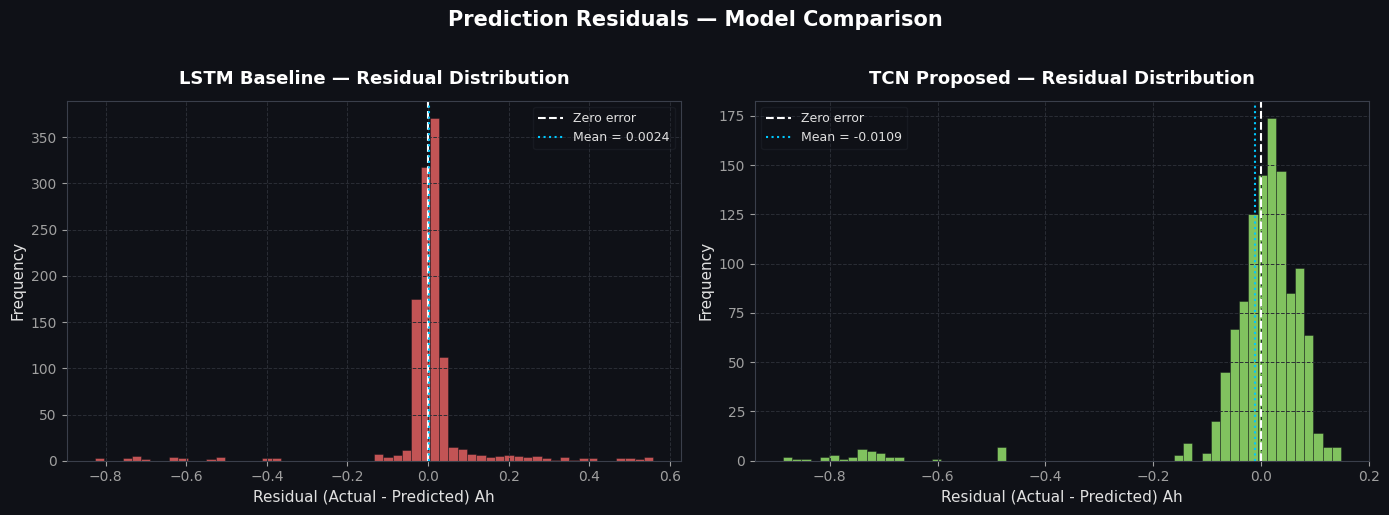

In [41]:
# New Cell - Residual Error Distribution

residuals_lstm = y_test_actual - y_pred_lstm_actual
residuals_tcn  = y_test_actual - y_pred_tcn_actual

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0f1117")

for ax, residuals, name, color in zip(
    axes,
    [residuals_lstm, residuals_tcn],
    ["LSTM Baseline", "TCN Proposed"],
    ["#ff6b6b", "#a8ff78"]
):
    ax.set_facecolor("#0f1117")
    ax.hist(residuals, bins=60, color=color,
            alpha=0.75, edgecolor="#0f1117", linewidth=0.4)
    ax.axvline(x=0, color="#ffffff", linewidth=1.5,
               linestyle="--", label="Zero error")
    ax.axvline(x=residuals.mean(), color="#00c8ff",
               linewidth=1.5, linestyle=":",
               label=f"Mean = {residuals.mean():.4f}")

    ax.set_title(f"{name} — Residual Distribution",
                 color="#ffffff", fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Residual (Actual - Predicted) Ah",
                  color="#e0e0e0", fontsize=11)
    ax.set_ylabel("Frequency", color="#e0e0e0", fontsize=11)
    ax.tick_params(colors="#a0a0a0")
    ax.grid(True, color="#2a2d35", linestyle="--", linewidth=0.7)
    ax.legend(fontsize=9, framealpha=0.2,
              edgecolor="#3a3f4b", labelcolor="#e0e0e0")
    for spine in ax.spines.values():
        spine.set_edgecolor("#3a3f4b")

plt.suptitle("Prediction Residuals — Model Comparison",
             fontsize=15, fontweight="bold", color="#ffffff", y=1.02)
plt.tight_layout()
plt.savefig("residual_distribution.png", dpi=150,
            bbox_inches="tight", facecolor="#0f1117")
plt.show()

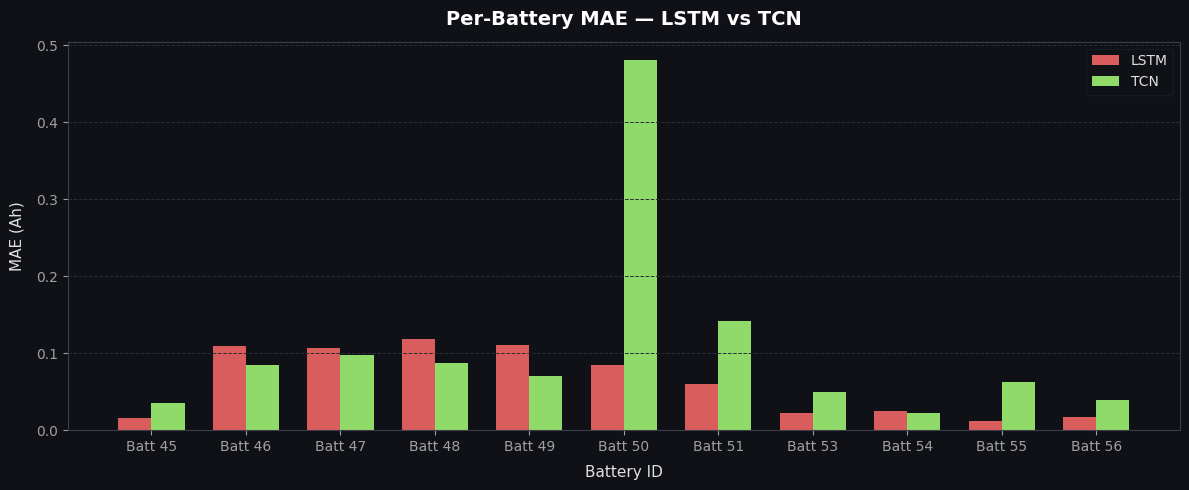

In [42]:
# New Cell - Per Battery MAE Comparison

unique_test_batteries = np.unique(test_battery_labels)

lstm_per_batt = []
tcn_per_batt  = []
batt_ids      = []

for bid in unique_test_batteries:
    mask = test_battery_labels == bid
    if mask.sum() < 5:
        continue
    lstm_per_batt.append(mean_absolute_error(
        y_test_actual[mask], y_pred_lstm_actual[mask]))
    tcn_per_batt.append(mean_absolute_error(
        y_test_actual[mask], y_pred_tcn_actual[mask]))
    batt_ids.append(f"Batt {int(bid)}")

x = np.arange(len(batt_ids))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#0f1117")

ax.bar(x - width/2, lstm_per_batt, width,
       label="LSTM", color="#ff6b6b", alpha=0.85)
ax.bar(x + width/2, tcn_per_batt, width,
       label="TCN",  color="#a8ff78", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(batt_ids, color="#a0a0a0", fontsize=10)
ax.set_xlabel("Battery ID", color="#e0e0e0", fontsize=11, labelpad=8)
ax.set_ylabel("MAE (Ah)", color="#e0e0e0", fontsize=11, labelpad=8)
ax.set_title("Per-Battery MAE — LSTM vs TCN",
             color="#ffffff", fontsize=14, fontweight="bold", pad=12)
ax.tick_params(colors="#a0a0a0")
ax.grid(True, axis="y", color="#2a2d35", linestyle="--", linewidth=0.7)
ax.legend(framealpha=0.2, edgecolor="#3a3f4b",
          fontsize=10, labelcolor="#e0e0e0")
for spine in ax.spines.values():
    spine.set_edgecolor("#3a3f4b")

plt.tight_layout()
plt.savefig("per_battery_mae.png", dpi=150,
            bbox_inches="tight", facecolor="#0f1117")
plt.show()

In [45]:
# Battery 50 Investigation Cell

bid_check = 50
mask_50 = test_battery_labels == bid_check

print(f"Battery {bid_check} — Test Set Analysis")
print("-" * 40)
print(f"Test samples     : {mask_50.sum()}")
print(f"Actual range     : {y_test_actual[mask_50].min():.4f} "
      f"to {y_test_actual[mask_50].max():.4f} Ah")
print(f"LSTM pred range  : {y_pred_lstm_actual[mask_50].min():.4f} "
      f"to {y_pred_lstm_actual[mask_50].max():.4f} Ah")
print(f"TCN  pred range  : {y_pred_tcn_actual[mask_50].min():.4f} "
      f"to {y_pred_tcn_actual[mask_50].max():.4f} Ah")
print(f"LSTM MAE         : {mean_absolute_error(y_test_actual[mask_50], y_pred_lstm_actual[mask_50]):.4f}")
print(f"TCN  MAE         : {mean_absolute_error(y_test_actual[mask_50], y_pred_tcn_actual[mask_50]):.4f}")

Battery 50 — Test Set Analysis
----------------------------------------
Test samples     : 7
Actual range     : 0.2454 to 0.2454 Ah
LSTM pred range  : 0.1538 to 0.1721 Ah
TCN  pred range  : 0.7186 to 0.7338 Ah
LSTM MAE         : 0.0851
TCN  MAE         : 0.4808
